In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import joblib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust the path below if your file is in a different location within your Drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Sanjana/RT_IOT2022.csv')

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(123117, 85)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_s

In [ ]:
df = df.dropna()

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']):
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop("flow_duration", axis=1)
y = df["flow_duration"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

In [ ]:
def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

In [ ]:
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("KNN", y_test, y_pred_knn)
evaluate("Gradient Boosting", y_test, y_pred_gbr)


Linear Regression
MAE: 0.0029593572293681604
RMSE: 0.07923855155057359
R2: 0.9999796561563143

Decision Tree
MAE: 0.02197392554012345
RMSE: 1.212056899263418
R2: 0.9952400107730643

Random Forest
MAE: 0.025045804407048712
RMSE: 1.5755554146025117
R2: 0.9919568286869697

KNN
MAE: 0.24341655224171538
RMSE: 6.38999050841642
R2: 0.8676998367917412

Gradient Boosting
MAE: 0.0483335066641739
RMSE: 0.5876342560455438
R2: 0.9988811440808694


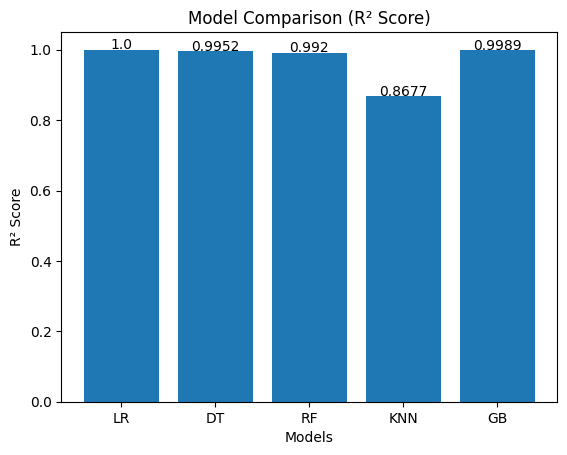

In [ ]:
models = ["LR", "DT", "RF", "KNN", "GB"]
r2_scores = [0.99998, 0.99524, 0.99196, 0.86770, 0.99888]

import matplotlib.pyplot as plt

plt.bar(models, r2_scores)
plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

# Add values on top
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.002, str(round(v, 4)), ha='center')

plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(lr, "linear_regression.model")
joblib.dump(dt, "decision_tree.model")
joblib.dump(rf, "random_forest.model")
joblib.dump(knn, "knn.model")
joblib.dump(gbr, "gradient_boosting.model")

['gradient_boosting.model']

In [ ]:
from google.colab import files

files.download("linear_regression.model")
files.download("decision_tree.model")
files.download("random_forest.model")
files.download("knn.model")
files.download("gradient_boosting.model")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>